# Import libs

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pickle
from io import StringIO
from datetime import datetime
from dateutil import parser  # more robust date parsing
import torch
from torch.utils.data import Dataset, DataLoader
from typing import Iterable, Optional, Union
import itertools, math, time, json, pathlib
from dataretrieval import nwis
from tenacity import retry, wait_fixed, stop_after_attempt


# Retrieve discharge data and save

In [2]:
def remove_outliers(
    df: pd.DataFrame,
    cols: Optional[Union[str, Iterable[str]]] = None,
    lower_pct: float = 0.5,
    upper_pct: float = 99.5,
    inplace: bool = False,
) -> pd.DataFrame:
    """
    Replace values below the lower percentile or above the
    upper percentile with those exact percentile values ("closest bounds").

    Parameters
    ----------
    df : pd.DataFrame
        Source dataframe.
    cols : str | Iterable[str] | None, optional
        Column or collection of columns to winsorize.  
        • If *None* (default), all numeric columns are processed.  
        • Non‑numeric columns are ignored silently.
    lower_pct : float, optional
        Lower percentile (0–100) that defines the lower bound. Default 0.5.
    upper_pct : float, optional
        Upper percentile (0–100) that defines the upper bound. Default 99.5.
    inplace : bool, optional
        If *True*, modify *df* in place and return it.  
        If *False* (default), work on a copy and return the copy.

    Returns
    -------
    pd.DataFrame
    """
    if lower_pct < 0 or upper_pct > 100 or lower_pct >= upper_pct:
        raise ValueError("Percentiles must satisfy 0 ≤ lower < upper ≤ 100.")

    if cols is None:
        # Select only numeric columns to avoid accidental dtype issues
        cols = df.select_dtypes(include="number").columns
    elif isinstance(cols, str):
        cols = [cols]

    working_df = df if inplace else df.copy()

    lo_q = lower_pct / 100.0
    hi_q = upper_pct / 100.0

    for col in cols:
        if col not in working_df.columns or not pd.api.types.is_numeric_dtype(
            working_df[col]
        ):
            # Skip silently for non‑existing or non‑numeric columns
            continue

        # Calculate the percentile bounds
        lower_bound, upper_bound = working_df[col].quantile([lo_q, hi_q]).values

        #drop anything outside [lower_bound, upper_bound] to the bound
        working_df[col] = working_df[col].clip(lower=lower_bound, upper=upper_bound)

    return working_df

def percentile_band_min_max(
    df: pd.DataFrame,
    col: str,
    step: float = 1.0,
    mask: Optional[pd.Series] = None,
):
    if col not in df.columns or not pd.api.types.is_numeric_dtype(df[col]):
        raise ValueError(f"Column {col!r} is missing or not numeric.")

    if step <= 0 or step > 100:
        raise ValueError("`step` must be in (0, 100].")

    # Apply an optional mask (handy if you want to exclude sentinels/outliers)
    data = df[col] if mask is None else df.loc[mask, col]

    # Build percentile cut‑points 0, step, 2*step, …, 100
    edges = np.arange(0, 100 + step, step)
    # pd.qcut will bucket each row into the corresponding percentile band
    # duplicates='drop' avoids errors if there are repeated quantile values
    bands = pd.qcut(data, q=edges / 100.0, labels=False, duplicates="drop")

    # Group by band index → min / max
    grouped = data.groupby(bands).agg(min="min", max="max")

    # Add readable percentile bounds
    grouped["p_low"] = grouped.index * step
    grouped["p_high"] = grouped["p_low"] + step
    # Re‑order & tidy up
    grouped = grouped[["p_low", "p_high", "min", "max"]].reset_index(drop=True)

    return grouped

In [8]:
# Define the URL with JSON format
url = ("https://waterservices.usgs.gov/nwis/dv/?format=json"
       "&stateCd=NJ"
       "&parameterCd=00060"
       "&startDT=2020-01-01"
       "&endDT=2024-12-31")

# Retrieve data from the API
response = requests.get(url)
if response.status_code != 200:
    raise Exception(f"Error retrieving data: {response.status_code}")

# Parse the JSON response
data = response.json()

# Prepare a list to hold the extracted rows
rows = []

# The time series data is nested in the JSON structure under data["value"]["timeSeries"]
for ts in data.get('value', {}).get('timeSeries', []):
    # Get site info (e.g., site name and site code)
    source_info = ts.get('sourceInfo', {})
    site_name = source_info.get('siteName')
    # The siteCode is usually a list; we use the first one
    site_codes = source_info.get('siteCode', [])
    site_code = site_codes[0].get('value') if site_codes else None

    # Get variable info (e.g., variable name)
    variable_info = ts.get('variable', {})
    variable_name = variable_info.get('variableName')

    # Extract measurement values from the nested "values" list
    for measurement in ts.get('values', []):
        for record in measurement.get('value', []):
            rows.append({
                "siteName": site_name,
                "siteCode": site_code,
                "variableName": variable_name,
                "dateTime": record.get('dateTime'),
                "value": record.get('value'),
                "qualifiers": ", ".join(record.get('qualifiers', []))
            })

# Create a pandas DataFrame from the extracted rows
df = pd.DataFrame(rows)
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df = remove_outliers(df, "value", 0.5, 99.5, inplace=True)

# Save the DataFrame to csv
csv_filename = 'data/usgs_discharge.csv'
df.to_csv(csv_filename, index=False)
print(f"Data successfully saved to '{csv_filename}'.")

summary = percentile_band_min_max(df, "value", step=1.0)
summary

Data successfully saved to 'data/usgs_discharge.csv'.


,p_low,p_high,min,max
0,0.0,1.0,0.23,0.60
1,1.0,2.0,0.61,1.14
2,2.0,3.0,1.15,1.56
3,3.0,4.0,1.57,1.97
4,4.0,5.0,1.98,2.50
...,...,...,...,...
95,95.0,96.0,962.00,1440.00
96,96.0,97.0,1450.00,2670.00
97,97.0,98.0,2680.00,5650.00
98,98.0,99.0,5660.00,11000.00


In [29]:
def retrieve_usgs_timeseries(stateCd: str,
                             parameterCd: str,
                             var_name: str,
                             startDT: str,
                             endDT: str,
                             out_csv: str):
    """
    Download a USGS DV time series for a single parameter, clean it, and save as CSV.
    """
    url = (
        f"https://waterservices.usgs.gov/nwis/dv/?format=json"
        f"&stateCd={stateCd}"
        f"&parameterCd={parameterCd}"
        f"&startDT={startDT}"
        f"&endDT={endDT}"
    )
    r = requests.get(url)
    if r.status_code != 200:
        raise RuntimeError(f"Error {r.status_code} retrieving {var_name} ({parameterCd})")
    js = r.json()
    json.dump(js, open(f"data/usgs_{var_name}.json", "w"), indent=2)
    
    rows = []
    if len(js.get("value", {}).get("timeSeries", [])) == 0:
        raise RuntimeError(f"No time series found for {var_name} ({parameterCd})")
    
    
    for ts in js.get("value", {}).get("timeSeries", []):
        src = ts["sourceInfo"]
        site_name = src["siteName"]
        site_code = src["siteCode"][0]["value"]
        vinfo = ts["variable"]
        for meas in ts.get("values", []):
            for rec in meas.get("value", []):
                rows.append({
                    "siteCode":    site_code,
                    "siteName":    site_name,
                    "variable":    var_name,
                    "dateTime":    rec["dateTime"][:10],
                    "value":       float(rec["value"]) if rec["value"] not in (None,"") else pd.NA
                })
    df = pd.DataFrame(rows)
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    
    # optional: remove outliers (you already have your remove_outliers function)
    df = remove_outliers(df, "value", 0.5, 99.5, inplace=False)
    
    df.to_csv(out_csv, index=False)
    print(f"Saved {var_name} → {out_csv}")
    return df

# --- parameter codes ---
params = {
    "00193": "total_precipitation",           # total precipitation (inches)
    "00045": "precipitation",           # precipitation (inches)
    "00010": "water_temp_celsius",     # water temp
    "00011": "water_temp_fahrenheit",     # water temp
    "00012": "evaporation_temp_48",          # 48-inch pan
    "00013": "evaporation_temp_24",          # 24-inch pan
    "00020": "air_temp_celsius",     # air temp
    "00021": "air_temp_fahrenheit",     # air temp
    "00030": "solar_radiation",    # solar radiation
    "00032": "cloud_cover",      # cloud cover
    "00035": "wind_speed",      # wind speed
    "00050": "evaporation_rate",      # evaporation rate
    "00052": "relative_humidity",      # relative humidity
}

# example date range
start, end = "2020-01-01", "2024-12-31"

# loop and pull each variable
for code, name in params.items():
    out_csv = f"data/usgs_{name}.csv"
    try:
        retrieve_usgs_timeseries(
            stateCd="NJ",
            parameterCd=code,
            var_name=name,
            startDT=start,
            endDT=end,
            out_csv=out_csv
        )
    except RuntimeError as e:
        print(f"Error retrieving {name}: {e}")

Error retrieving total_precipitation: No time series found for total_precipitation (00193)
Saved precipitation → data/usgs_precipitation.csv
Saved water_temp_celsius → data/usgs_water_temp_celsius.csv
Error retrieving water_temp_fahrenheit: No time series found for water_temp_fahrenheit (00011)
Error retrieving evaporation_temp_48: No time series found for evaporation_temp_48 (00012)
Error retrieving evaporation_temp_24: No time series found for evaporation_temp_24 (00013)
Saved air_temp_celsius → data/usgs_air_temp_celsius.csv
Error retrieving air_temp_fahrenheit: No time series found for air_temp_fahrenheit (00021)
Error retrieving solar_radiation: No time series found for solar_radiation (00030)
Error retrieving cloud_cover: No time series found for cloud_cover (00032)
Error retrieving wind_speed: No time series found for wind_speed (00035)
Error retrieving evaporation_rate: No time series found for evaporation_rate (00050)
Error retrieving relative_humidity: No time series found fo

In [15]:
var_files = {
    "discharge"      : "data/usgs_discharge.csv",
    "precipitation"         : "data/usgs_precipitation.csv",
    "air_temp_celsius"      : "data/usgs_air_temp_celsius.csv",
    "water_temp_celsius"      : "data/usgs_water_temp_celsius.csv",
}

# Read each file, store the DataFrame in a dict keyed by variable name
var_dfs = {name: pd.read_csv(path) for name, path in var_files.items()}

for name, df in var_dfs.items():
    summary = percentile_band_min_max(df, "value", step=1.0)
    print(f"Summary for {name}:")
    print(summary)

Summary for discharge:
    p_low  p_high       min       max
0     0.0     1.0      0.23      0.60
1     1.0     2.0      0.61      1.14
2     2.0     3.0      1.15      1.56
3     3.0     4.0      1.57      1.97
4     4.0     5.0      1.98      2.50
..    ...     ...       ...       ...
95   95.0    96.0    962.00   1440.00
96   96.0    97.0   1450.00   2670.00
97   97.0    98.0   2680.00   5650.00
98   98.0    99.0   5660.00  11000.00
99   99.0   100.0  11100.00  15800.00

[100 rows x 4 columns]
Summary for precipitation:
    p_low  p_high   min   max
0     0.0     1.0  0.00  0.01
1     1.0     2.0  0.02  0.02
2     2.0     3.0  0.03  0.03
3     3.0     4.0  0.04  0.04
4     4.0     5.0  0.05  0.06
5     5.0     6.0  0.07  0.07
6     6.0     7.0  0.08  0.08
7     7.0     8.0  0.09  0.10
8     8.0     9.0  0.11  0.12
9     9.0    10.0  0.13  0.14
10   10.0    11.0  0.15  0.17
11   11.0    12.0  0.18  0.20
12   12.0    13.0  0.21  0.23
13   13.0    14.0  0.24  0.26
14   14.0    15.0  0

In [16]:
for name, df in var_dfs.items():
    print(f"Describe for {name}:")
    print(df.describe())

Describe for discharge:
           siteCode          value
count  2.101280e+05  210128.000000
mean   2.624747e+06     379.595964
std    1.321203e+07    1707.600616
min    1.377000e+06       0.230000
25%    1.389500e+06      13.600000
50%    1.403400e+06      38.300000
75%    1.443280e+06     120.000000
max    1.465873e+08   15800.000000
Describe for precipitation:
           siteCode         value
count  1.514600e+04  15146.000000
mean   4.020032e+14      0.104278
std    5.145187e+12      0.286062
min    3.856551e+14      0.000000
25%    4.002261e+14      0.000000
50%    4.035061e+14      0.000000
75%    4.048221e+14      0.020000
max    4.111301e+14      1.920000
Describe for air_temp_celsius:
           siteCode         value
count  8.895500e+04  88955.000000
mean   8.405621e+06     13.329588
std    3.098572e+07     10.181817
min    1.411456e+06    -11.100000
25%    1.456050e+06      5.400000
50%    1.465950e+06     14.100000
75%    1.466620e+06     21.300000
max    1.467003e+08     

In [11]:
for name, df in var_dfs.items():
    print(f"Null count for {name}:")
    print(df.isna().sum())

Null count for discharge:
siteName        0
siteCode        0
variableName    0
dateTime        0
value           0
qualifiers      0
dtype: int64
Null count for precip:
siteCode    0
siteName    0
variable    0
dateTime    0
value       0
dtype: int64
Null count for t_air:
siteCode    0
siteName    0
variable    0
dateTime    0
value       0
dtype: int64
Null count for t_water:
siteCode    0
siteName    0
variable    0
dateTime    0
value       0
dtype: int64


# Retrieve site and location

In [9]:

# Define the URL for the USGS Site Service in RDB format for New Jersey.
url = "https://waterservices.usgs.gov/nwis/site/?format=rdb&stateCd=NJ"

# Retrieve data from the API
response = requests.get(url)
if response.status_code != 200:
    raise Exception(f"Error retrieving site data: {response.status_code}")

# Save the RDB response text to a file
rdb_filename = "data/usgs_site_info.rdb"
with open(rdb_filename, 'w') as file:
    file.write(response.text)
print(f"RDB data successfully saved to '{rdb_filename}'.")

# Read and parse the RDB file:
# 1. Skip comment lines (starting with '#') and any blank lines.
# 2. The first non-comment line is the header.
# 3. The second non-comment line is a dashes line that should be skipped.
with open(rdb_filename, 'r') as file:
    lines = file.readlines()

# Filter out comment lines and empty lines
lines = [line for line in lines if not line.startswith('#') and line.strip() != '']

if len(lines) < 2:
    raise Exception("The file does not contain enough lines to parse header and data.")

# The first line is the header; the second line is the dashes row; the rest are data
header = lines[0].strip().split('\t')
data_lines = lines[2:]  # skip the dashes row

# Combine the data lines into one string so that we can use StringIO
data_str = "".join(data_lines)

# Load the data into a pandas DataFrame
df_sites = pd.read_csv(StringIO(data_str), sep='\t', names=header)
print("Data loaded into DataFrame.")

# Save the DataFrame to a CSV file
csv_filename = "data/usgs_site_info.csv"
df_sites.to_csv(csv_filename, index=False)
print(f"Site information successfully saved to '{csv_filename}'.")


RDB data successfully saved to 'data/usgs_site_info.rdb'.
Data loaded into DataFrame.
Site information successfully saved to 'data/usgs_site_info.csv'.


In [10]:
print(f"Site information successfully saved to '{csv_filename}'.")

# (Optional) Load and display the first few rows for inspection
df_inspect = pd.read_csv(csv_filename, nrows=1000)
df_inspect.head()

Site information successfully saved to 'data/usgs_site_info.csv'.


,agency_cd,site_no,station_nm,site_tp_cd,dec_lat_va,dec_long_va,coord_acy_cd,dec_coord_datum_cd,alt_va,alt_acy_va,alt_datum_cd,huc_cd
0,USGS,1367612,Lake Mohawk 2.9 mi upstream of dam near Sparta NJ,LK,41.004639,-74.683500,S,NAD83,730.0,5.0,NAVD88,2020007.0
1,USGS,1367613,Lake Mohawk 2.2 mi upstream of dam near Sparta NJ,LK,41.009306,-74.675083,S,NAD83,730.0,5.0,NAVD88,2020007.0
2,USGS,1367614,Lake Mohawk 1.3 mi upstream of dam near Sparta NJ,LK,41.017611,-74.657806,S,NAD83,730.0,5.0,NAVD88,2020007.0
3,USGS,1367615,Lake Mohawk 1.2 mi upstream of dam near Sparta NJ,LK,41.022111,-74.660750,S,NAD83,730.0,5.0,NAVD88,2020007.0
4,USGS,1367616,Lake Mohawk 3800 ft upstream of dam at Sparta NJ,LK,41.025083,-74.651889,S,NAD83,730.0,5.0,NAVD88,2020007.0


# Construcitng graph

In [ ]:
# Function to calculate Haversine distance between two points (in kilometers)
def haversine(lat1, lon1, lat2, lon2):
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    # Haversine formula
    dlat = lat2 - lat1 
    dlon = lon2 - lon1 
    a = math.sin(dlat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    r = 6371  # Earth radius in kilometers
    return c * r

# -----------------------------
# 1. Load Data
# -----------------------------
# Load site information and gage height time series data
site_csv        = "data/usgs_site_info.csv"
df_sites        = pd.read_csv(site_csv)

basin_csv       = "data/nj_basin_characteristics.csv"   # <- path you saved earlier
df_basin        = pd.read_csv(basin_csv, dtype={"site_no": str})
df_basin.set_index("site_no", inplace=True)

# pick the attributes you actually care about  ───────────────
BASIN_ATTRS = [
    "DRNAREA",       # drainage area (sq mi)
    "BSLOPE",        # mean basin slope (%)
    "FORESTNL",      # % forest + natural land cover
    "PPTAVG_BASIN",  # mean annual precip (in)
]

# Map <variable name> → csv path
var_files = {
    "discharge"      : "data/usgs_discharge.csv",
    "precip"         : "data/usgs_precipitation.csv",
    "t_air"      :      "data/usgs_air_temperature.csv",
    "t_water"      : "data/usgs_water_temperature.csv",
}

# Read each file, store the DataFrame in a dict keyed by variable name
var_dfs = {name: pd.read_csv(path) for name, path in var_files.items()}
sites_discharge = set(var_dfs["discharge"]["siteCode"].unique())
sites_with_data = sites_discharge   

df_sites_filtered = df_sites[df_sites["site_no"].isin(sites_with_data)].copy()

# -----------------------------
# 3. Construct the Graph with Filtered Site Nodes
# -----------------------------
G = nx.Graph()

# Add each filtered site as a node
for idx, row in df_sites_filtered.iterrows():
    site_id = row['site_no']
    attrs = {
        "siteName" : site_id,
        "latitude" : row["dec_lat_va"],
        "longitude": row["dec_long_va"],
    }

    # attach basin characteristics (NaN → None)
    if site_id in df_basin.index:
        for code in BASIN_ATTRS:
            val = df_basin.at[site_id, code]
            attrs[code] = None if pd.isna(val) else float(val)

    G.add_node(site_id, **attrs)
    
# -----------------------------
# 4. Compute Pairwise Distances Between Sites
# -----------------------------
nodes = list(G.nodes(data=True))
distance_dict = {}

# Compute pairwise distances using the Haversine formula
for i in range(len(nodes)):
    for j in range(i + 1, len(nodes)):
        site1, data1 = nodes[i]
        site2, data2 = nodes[j]
        dist = haversine(data1['latitude'], data1['longitude'],
                         data2['latitude'], data2['longitude'])
        distance_dict[(site1, site2)] = dist

# -----------------------------
# 5. Determine the 90th Percentile Distance Threshold and Add Edges
# -----------------------------
all_distances = list(distance_dict.values())
print(all_distances[:50])
threshold = np.percentile(all_distances, 90)
print(f"90th percentile distance threshold: {threshold:.2f} km")

# Add edges only for distances <= 90th percentile threshold
for (site1, site2), dist in distance_dict.items():
    if dist <= threshold:
        normalized_distance = dist / threshold if threshold else 0
        G.add_edge(site1, site2, distance=dist, normalized_distance=normalized_distance)

print(f"Graph constructed with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges (filtered by 90th percentile).")

# -----------------------------
# 6. Attach Gage Height Time Series Data as Node Attributes
# -----------------------------
# Group the gage height data by siteCode
grouped_by_site = {var: df.groupby("siteCode") for var, df in var_dfs.items()}

for site in G.nodes():
    # For every variable, pull that site’s records (to_dict list) if present
    for var, g in grouped_by_site.items():
        if site in g.groups:
            series = g.get_group(site)[["dateTime", "value"]].to_dict("records")
        else:
            series = []                      # missing for this site
        G.nodes[site][f"{var}_series"] = series

# -----------------------------
# 7. Save the Graph for Later Use
# -----------------------------
graph_filename = "data/usgs_graph_filtered_multivar.gpickle"
with open(graph_filename, "wb") as f:
    pickle.dump(G, f)
print(f"Graph saved to '{graph_filename}'.")


119 sites kept (out of 11843)
Describe for filtered sites:
            site_no  dec_lat_va  dec_long_va      alt_va  alt_acy_va  \
count  1.190000e+02  119.000000   119.000000  115.000000  115.000000   
mean   2.632037e+06   40.479593   -74.562418  161.637739    6.526696   
std    1.330823e+07    0.502731     0.334676  194.405054   65.254717   
min    1.377000e+06   39.306944   -75.330278    0.000000    0.010000   
25%    1.389525e+06   40.141944   -74.824167   23.515000    0.010000   
50%    1.403400e+06   40.635472   -74.539722   89.460000    0.010000   
75%    1.441640e+06   40.895694   -74.288194  220.045000    0.020000   
max    1.465873e+08   41.160278   -73.989167  904.990000  700.000000   

             huc_cd  
count  1.190000e+02  
mean   2.034345e+06  
std    5.003303e+03  
min    2.030103e+06  
25%    2.030103e+06  
50%    2.030105e+06  
75%    2.040202e+06  
max    2.040302e+06  
Null count for filtered sites:
agency_cd             0
site_no               0
station_nm     

Graph saved to 'data/usgs_graph_filtered_multivar.gpickle'.


In [12]:
summary = percentile_band_min_max(df_discharge, "value", step=1.0)
summary

,p_low,p_high,min,max
0,0.0,1.0,0.23,0.59
1,1.0,2.0,0.60,1.13
2,2.0,3.0,1.14,1.56
3,3.0,4.0,1.57,1.96
4,4.0,5.0,1.97,2.50
...,...,...,...,...
95,95.0,96.0,963.00,1440.00
96,96.0,97.0,1450.00,2670.00
97,97.0,98.0,2680.00,5650.00
98,98.0,99.0,5660.00,11000.00


Graph constructed with 119 nodes and 6319 edges.


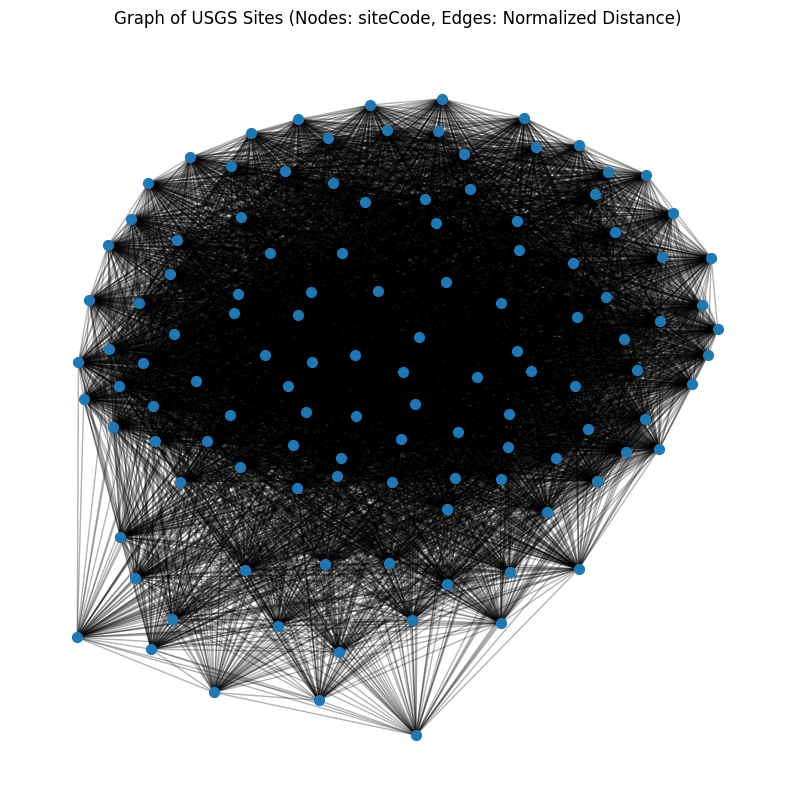

In [13]:
print(f"Graph constructed with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

# Visualize the graph (note: for a complete graph, the drawing may be cluttered)
# Using a spring layout for a simple visualization
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(10, 10))
nx.draw_networkx_nodes(G, pos, node_size=50)
nx.draw_networkx_edges(G, pos, alpha=0.3)
plt.title("Graph of USGS Sites (Nodes: siteCode, Edges: Normalized Distance)")
plt.axis("off")
plt.show()

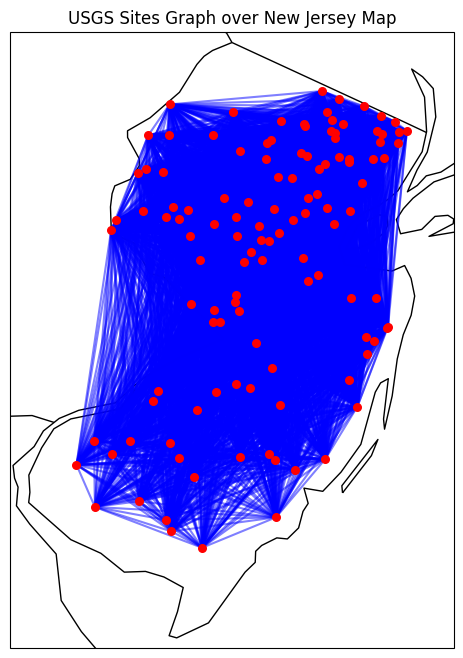

In [14]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Create a new figure with a PlateCarree projection
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set the extent to cover New Jersey
# (longitude: ~ -75.6 to -73.8, latitude: ~ 38.9 to 41.4)
ax.set_extent([-75.6, -73.8, 38.9, 41.4], crs=ccrs.PlateCarree())

# Add state boundaries using Natural Earth admin-1 lines
states_provinces = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='50m',
    facecolor='none'
)
ax.add_feature(states_provinces, edgecolor='black', linewidth=1)

# Optionally, add coastlines and country borders for additional context
ax.coastlines(resolution='50m', linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=1)

# Plot the graph edges
# For each edge, draw a line connecting the nodes (using their longitude and latitude)
for site1, site2, attr in G.edges(data=True):
    lon1, lat1 = G.nodes[site1]['longitude'], G.nodes[site1]['latitude']
    lon2, lat2 = G.nodes[site2]['longitude'], G.nodes[site2]['latitude']
    ax.plot([lon1, lon2], [lat1, lat2], transform=ccrs.PlateCarree(),
            color='blue', alpha=0.5)

# Plot the graph nodes
lons = [data['longitude'] for _, data in G.nodes(data=True)]
lats = [data['latitude'] for _, data in G.nodes(data=True)]
ax.scatter(lons, lats, transform=ccrs.PlateCarree(), color='red', s=30, zorder=5)

# Add title and labels
plt.title("USGS Sites Graph over New Jersey Map")
plt.show()


In [15]:
# Iterate over each node in the graph
for node, data in G.nodes(data=True):
    # Check if the node has a gage_height_series attribute
    if 'discharge_series' in data:
        # Create a new list with only dateTime and value for each record
        simplified_series = [
            {'dateTime': record.get('dateTime'), 'value': record.get('value')}
            for record in data['discharge_series']
            if 'dateTime' in record and 'value' in record
        ]
        # Replace the original series with the simplified version
        G.nodes[node]['discharge_series'] = simplified_series

# Optionally, print the updated attributes of one node to verify
node_example = list(G.nodes(data=True))[0]
print(node_example)

(1377000, {'siteName': 1377000, 'latitude': 40.99916667, 'longitude': -73.9891667, 'discharge_series': [{'dateTime': '2020-01-01T00:00:00.000', 'value': 217.0}, {'dateTime': '2020-01-02T00:00:00.000', 'value': 150.0}, {'dateTime': '2020-01-03T00:00:00.000', 'value': 120.0}, {'dateTime': '2020-01-04T00:00:00.000', 'value': 119.0}, {'dateTime': '2020-01-05T00:00:00.000', 'value': 114.0}, {'dateTime': '2020-01-06T00:00:00.000', 'value': 91.5}, {'dateTime': '2020-01-07T00:00:00.000', 'value': 77.8}, {'dateTime': '2020-01-08T00:00:00.000', 'value': 67.5}, {'dateTime': '2020-01-09T00:00:00.000', 'value': 59.4}, {'dateTime': '2020-01-10T00:00:00.000', 'value': 52.0}, {'dateTime': '2020-01-11T00:00:00.000', 'value': 48.7}, {'dateTime': '2020-01-12T00:00:00.000', 'value': 51.6}, {'dateTime': '2020-01-13T00:00:00.000', 'value': 58.5}, {'dateTime': '2020-01-14T00:00:00.000', 'value': 54.8}, {'dateTime': '2020-01-15T00:00:00.000', 'value': 52.7}, {'dateTime': '2020-01-16T00:00:00.000', 'value': 52

In [24]:

def min_max_scale_features(X, min_val=0.0, max_val=1.0):
    """
    Scales the features to a specified range [min_val, max_val].

    Args:
        X (torch.Tensor): Input tensor of shape (n, f).
        min_val (float): Minimum value of the scaled data.
        max_val (float): Maximum value of the scaled data.

    Returns:
        torch.Tensor: Min-max scaled tensor.
    """
    X_min = X.min(dim=0, keepdim=True)[0]
    X_max = X.max(dim=0, keepdim=True)[0]
    # To avoid division by zero
    X_max[X_max == X_min] = X_min[X_max == X_min] + 1.0
    X_scaled = (X - X_min) / (X_max - X_min)
    X_scaled = X_scaled * (max_val - min_val) + min_val
    return X_scaled

def parse_date(date_str):
    """
    Parse an ISO date string (e.g., '2024-01-01T00:00:00.000') into a datetime object.
    """
    return parser.parse(date_str)

def extract_series_from_node(node_data, start_date, end_date):
    """
    Given node data (a dictionary containing 'gage_height_series'),
    filter the series to the given [start_date, end_date] and return:
      - A list of datetime objects (sorted) as the reference time index.
      - A NumPy array of the corresponding values.
    """
    series = node_data.get('discharge_series', [])
    filtered = []
    for record in series:
        try:
            dt = parse_date(record['dateTime'])
            if start_date <= dt <= end_date:
                filtered.append((dt, float(record['value'])))
        except Exception as e:
            continue
    # Sort by date
    filtered.sort(key=lambda x: x[0])
    dates = [x[0] for x in filtered]
    values = [x[1] for x in filtered]
    return dates, np.array(values)

# ================================
# 2. Build Node Feature Matrix
# ================================

def build_node_feature_matrix(G, start_date, end_date):
    """
    For each node in graph G, extract its time series values within [start_date, end_date],
    align them on a common time index (union of all dates), and return:
      - A feature matrix X of shape (num_nodes, T), where T is the number of common time steps.
      - The common sorted time index (list of datetime objects).
      - The list of node identifiers (in the same order as the rows of X).
    Missing values are filled with np.nan.
    """
    nodes = list(G.nodes())
    # Store each node's dates and values, and build the union of all dates.
    node_series = {}
    common_dates = set()
    for node in nodes:
        dates, values = extract_series_from_node(G.nodes[node], start_date, end_date)
        node_series[node] = (dates, values)
        common_dates.update(dates)
    
    # Create a sorted list of common dates
    common_dates = sorted(common_dates)
    print(len(common_dates))
    # Build the feature matrix by aligning each node's series to the common_dates.
    matrix = []
    for node in nodes:
        dates, values = node_series[node]
        # Create a dictionary for quick lookup
        date_value_map = {d: v for d, v in zip(dates, values)}
        # Align the values: if a date is missing for a node, fill with 0
        aligned_values = [date_value_map.get(d, 0) for d in common_dates]
        matrix.append(aligned_values)
    
    X = np.array(matrix)  # shape: (num_nodes, T)
    return X, common_dates, nodes

# ========================================
# 3. Build Sliding Window Train-Val Dataset
# ========================================

def build_dataset(data_matrix, input_len, target_len):
    """
    Given a data matrix of shape (num_nodes, T), create a dataset using a sliding window.
    Each sample:
      - X_sample has shape (num_nodes, input_len)
      - Y_sample has shape (num_nodes, target_len)
    Returns:
      - X_samples: shape (num_samples, num_nodes, input_len)
      - Y_samples: shape (num_samples, num_nodes, target_len)
    Raises a ValueError if there is insufficient data.
    """
    num_nodes, T = data_matrix.shape
    num_samples = T - (input_len + target_len) + 1

    if num_samples < 1:
        raise ValueError(
            f"Not enough data points to create sliding windows. "
            f"Time steps (T) = {T} but require at least {input_len + target_len}."
        )

    X_samples = []
    Y_samples = []
    for i in range(num_samples):
        X_sample = min_max_scale_features(torch.Tensor(data_matrix[:, i:i + input_len]), 0, 1)
        Y_sample = min_max_scale_features(torch.Tensor(data_matrix[:, i + input_len:i + input_len + target_len]), 0, 1)
        X_samples.append(X_sample)
        Y_samples.append(Y_sample)
    
    X_samples = np.stack(X_samples, axis=0)
    Y_samples = np.stack(Y_samples, axis=0)
    return X_samples, Y_samples



# ================================
# 4. Build the Adjacency Matrix
# ================================

def build_adjacency_matrix(G, nodes_order):
    """
    Build a binary adjacency matrix (NumPy array) for graph G.
    The order of nodes in the matrix is given by nodes_order.
    """
    num_nodes = len(nodes_order)
    A = np.zeros((num_nodes, num_nodes))
    node_to_index = {node: i for i, node in enumerate(nodes_order)}
    for u, v in G.edges():
        i = node_to_index[u]
        j = node_to_index[v]
        A[i, j] = 1
        A[j, i] = 1  # undirected graph
    return A

# ================================
# 5. Organize Data into Train and Val Sets
# ================================

# Define the date ranges
train_start = datetime(2023, 1, 1)
train_end   = datetime(2023, 10, 31)  # Training period: January - October 2024
val_start   = datetime(2024, 1, 1)
val_end     = datetime(2024, 12, 31)   # Validation period: November - December 2024

# Preset sequence lengths
input_seq_len = 50
target_seq_len = 25

# --- Build node feature matrices for each period ---
train_matrix, train_dates, nodes_order = build_node_feature_matrix(G, train_start, train_end)
val_matrix, val_dates, _ = build_node_feature_matrix(G, val_start, val_end)

# --- Build the train and validation datasets using sliding windows ---
# Example usage:
try:    
    X_train, Y_train = build_dataset(train_matrix, input_seq_len, target_seq_len)
    X_val, Y_val     = build_dataset(val_matrix, input_seq_len, target_seq_len)
    print("Training samples shape:", X_train.shape)
except ValueError as e:
    print("Error creating dataset:", e)

# --- Build the adjacency matrix using the node order from the feature matrix ---
A = build_adjacency_matrix(G, nodes_order)

# ================================
# 6. Print Shapes and Summary
# ================================

print("Training dataset shapes:")
print("  X_train:", X_train.shape)  # (num_samples_train, num_nodes, input_seq_len)
print("  Y_train:", Y_train.shape)  # (num_samples_train, num_nodes, target_seq_len)
print("Validation dataset shapes:")
print("  X_val:", X_val.shape)      # (num_samples_val, num_nodes, input_seq_len)
print("  Y_val:", Y_val.shape)      # (num_samples_val, num_nodes, target_seq_len)
print("Adjacency matrix shape:", A.shape)  # (num_nodes, num_nodes)

304
366
Training samples shape: (230, 118, 50)
Training dataset shapes:
  X_train: (230, 118, 50)
  Y_train: (230, 118, 25)
Validation dataset shapes:
  X_val: (292, 118, 50)
  Y_val: (292, 118, 25)
Adjacency matrix shape: (118, 118)


In [25]:
def build_weighted_adjacency_matrix(G, nodes_order):
    """
    Construct a weighted adjacency matrix where each entry is the normalized distance
    between nodes (if an edge exists) and 0 otherwise.
    
    Args:
        G (networkx.Graph): Graph where each edge has a 'normalized_distance' attribute.
        nodes_order (list): List of node identifiers in the order that will correspond to the rows/columns.
        
    Returns:
        A (np.ndarray): Weighted adjacency matrix of shape (num_nodes, num_nodes)
    """
    num_nodes = len(nodes_order)
    A = np.zeros((num_nodes, num_nodes), dtype=float)
    node_to_index = {node: i for i, node in enumerate(nodes_order)}
    for u, v, data in G.edges(data=True):
        i = node_to_index[u]
        j = node_to_index[v]
        # Use the normalized distance stored as an edge attribute; default to 0.0 if not found.
        normalized_distance = data.get('normalized_distance', 0.0)
        A[i, j] = normalized_distance
        A[j, i] = normalized_distance  # for an undirected graph
    return A

def adj_to_edge_index_and_attr(A):
    """
    Converts an adjacency matrix A (NumPy array) to PyTorch Geometric's edge_index and edge_attr.
    
    Args:
        A (np.ndarray): Adjacency matrix of shape (num_nodes, num_nodes). Can be binary or weighted.
    
    Returns:
        edge_index (torch.LongTensor): Tensor of shape [2, num_edges].
        edge_attr (torch.FloatTensor): Tensor of shape [num_edges] containing edge attributes.
    """
    # Find indices where A is nonzero
    row, col = np.nonzero(A)
    edge_index = torch.tensor([row, col], dtype=torch.long)
    # Get corresponding edge attributes (if A is binary, these will be ones; if weighted, the actual weights)
    edge_attr = torch.tensor(A[row, col], dtype=torch.float)
    return edge_index, edge_attr

A_weighted = build_weighted_adjacency_matrix(G, nodes_order)

# Convert the weighted adjacency matrix into edge_index and edge_attr.
edge_index, edge_attr = adj_to_edge_index_and_attr(A_weighted)

In [26]:
edge_attr.shape

torch.Size([12424])

In [27]:
class Config:
    def __init__(self):
        """
        Args:
            seq_len (int): Length of the input sequence per node.
            num_gat_heads (int): Number of attention heads for each GATv2Conv layer.
            num_gcn (int): Number of GATv2Conv layers.
            lstm_hidden (int): Hidden state dimension for the LSTM.
            pred_len (int): Number of time steps to predict.
        """
        self.seq_len= 50
        self.num_gat_heads = 8
        self.num_gcn= 2
        self.lstm_hidden= 64
        self.pred_len= 25
        self.num_lstm = 2
        self.batch_size = 32
        self.num_nodes = 41
# Create a config instance with example hyperparameters:
config = Config()


In [28]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, Y):
        """
        Args:
            X (np.array): Input features with shape (num_samples, num_nodes, input_seq_len)
            Y (np.array): Target sequences with shape (num_samples, num_nodes, target_seq_len)
        """
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)
    
    def __len__(self):
        return self.X.shape[0]
    
    def __getitem__(self, idx):
        # Returns a tuple (input_features, target_sequence) for the given index
        return self.X[idx], self.Y[idx]

# Create datasets from the numpy arrays
train_dataset = TimeSeriesDataset(X_train, Y_train)
val_dataset = TimeSeriesDataset(X_val, Y_val)

# Create DataLoaders for batch processing during training
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)

# Example: Iterate over one batch from the training DataLoader
for batch_X, batch_Y in train_loader:
    print("Batch X shape:", batch_X.shape)  # Expected: (batch_size, num_nodes, input_seq_len)
    print("Batch Y shape:", batch_Y.shape)  # Expected: (batch_size, num_nodes, target_seq_len)
    break

Batch X shape: torch.Size([32, 118, 50])
Batch Y shape: torch.Size([32, 118, 25])


# 22/04/2025: Retrieve site data

In [ ]:
import csv
from pathlib import Path
import pandas as pd, requests, io, sys, time
import logging
from concurrent.futures import ThreadPoolExecutor, as_completed
import threading

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)s  %(message)s",
    datefmt="%H:%M:%S"
)

########################
# 1. Get NJ gage list  #
########################

def get_nj_gages(site_type="ST"):
    """
    Return a DataFrame of all USGS stream‑gage coordinates in New Jersey.

    Columns: site_no, lat, lon
    """
    base = "https://waterservices.usgs.gov/nwis/site/"
    params = {
        "stateCd": "NJ",
        "format":  "rdb",        # tab‑delimited; never 400s
        "siteStatus": "all",
        "siteType":  site_type,  # 'ST' = stream‑gage stations
    }

    r = requests.get(base, params=params, timeout=30)
    try:
        r.raise_for_status()      # will raise on 4xx/5xx
    except requests.HTTPError as e:
        sys.exit(f"HTTP {r.status_code}: {e}")

    # Strip comment lines (start with '#') and load as TSV
    clean = "\n".join(
        ln for ln in r.text.splitlines() if not ln.startswith("#")
    )
    df = pd.read_csv(io.StringIO(clean), sep=r"\t", dtype=str)

    # keep USGS rows only
    df = df[df["agency_cd"] == "USGS"].copy()
    df["lat"] = df["dec_lat_va"].astype(float)
    df["lon"] = df["dec_long_va"].astype(float)
    return df[["site_no", "lat", "lon"]]

# --- demo ---
try:
    gages = get_nj_gages()
    print(f"Fetched {len(gages)} NJ stream gages")
except SystemExit as err:
    print(err)

# ──────────── CONFIG ────────────
MAX_WORKERS   = 8             # threads · keep ≤10 to stay API-friendly
RATE_LIMIT    = 40            # requests per minute allowed for the whole pool
TIMEOUT       = 300           # seconds per request
OUTFILE       = Path("nj_basin_characteristics.csv")
# ────────────────────────────────

# 1. ───── resume support ─────
if OUTFILE.exists():
    done = pd.read_csv(OUTFILE, usecols=["site_no"])["site_no"].astype(str).tolist()
    gages = gages[~gages["site_no"].isin(done)]
    print(f"Resuming: {len(done)} sites already done, {len(gages)} left.")
else:
    # write header lazily on first row
    OUTFILE.write_text("")    

# 2. ───── global rate limiter ─────
# every request acquires 1 token; token bucket refills every 60/RATE_LIMIT s
token = threading.Semaphore(RATE_LIMIT)
def token_refill():
    while True:
        time.sleep(60 / RATE_LIMIT)
        try:
            token.release()
        except ValueError:    # bucket already full
            pass
threading.Thread(target=token_refill, daemon=True).start()

# 3. ───── single-site worker ─────
session = requests.Session()          # connection pool shared by all threads
lock    = threading.Lock()            # serialize CSV writes

def fetch_site(rec):
    site_no, lat, lon = rec
    # rate-limit
    token.acquire()
    params = {
        "rcode": "NJ",
        "xlocation": lon,
        "ylocation": lat,
        "crs": 4326,
        "includeparameters": "true",
        "simplify": "true"          # polygons simplified → faster
    }
    url = "https://streamstats.usgs.gov/streamstatsservices/watershed.geojson"

    for attempt in range(4):         # 1 original + 3 retries
        try:
            r = session.get(url, params=params, timeout=TIMEOUT)
            r.raise_for_status()
            js = r.json()
            break
        except (requests.ReadTimeout, requests.ConnectionError):
            time.sleep(attempt)   # exponential back-off
    else:
        return None                  # give up after 4 attempts

    row = {"site_no": site_no}
    for p in js.get("parameters", []):
        key = (p.get("code") or p.get("name") or "").strip().replace(" ", "_")
        if key:
            row[key] = p.get("value")

    # thread-safe append
    with lock, OUTFILE.open("a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=row.keys())
        if f.tell() == 0:            # first ever write → header
            w.writeheader()
        w.writerow(row)

    return site_no                   # success flag

# 4. ───── thread pool orchestration ─────
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
    jobs = {pool.submit(fetch_site, rec): rec[0] for rec in gages.itertuples(index=False)}
    for fut in as_completed(jobs):
        sid = jobs[fut]
        try:
            if fut.result() is None:
                print(f"ERROR: {sid}  failed after retries")
            else:
                print(f"Sucess: {sid}")
        except Exception as e:
            print(f"ERROR: {sid}  unhandled error: {e}")



/tmp/ipykernel_2121311/272983075.py:42: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv(io.StringIO(clean), sep=r"\t", dtype=str)


Fetched 2957 NJ stream gages
Resuming: 406 sites already done, 2957 left.
ERROR: 01367620  failed after retries
ERROR: 01367625  failed after retries
ERROR: 01367650  failed after retries
ERROR: 01367648  failed after retries
ERROR: 01367640  failed after retries
ERROR: 01367631  failed after retries
ERROR: 01367638  failed after retries
ERROR: 01367633  failed after retries
ERROR: 01367705  failed after retries
ERROR: 01367718  failed after retries
ERROR: 01367715  failed after retries
ERROR: 01367700  failed after retries
ERROR: 01367693  failed after retries
ERROR: 01367690  failed after retries
ERROR: 01367702  failed after retries
ERROR: 01367701  failed after retries
ERROR: 01367729  failed after retries
ERROR: 01367726  failed after retries
ERROR: 01367735  failed after retries
ERROR: 01367780  failed after retries
ERROR: 01367785  failed after retries
ERROR: 01367750  failed after retries
ERROR: 01367770  failed after retries
ERROR: 01367795  failed after retries
ERROR: 0136786

In [30]:
from torch_geometric.data import Data, Batch


model = GraphLSTM(config)
for batch_X, batch_Y in train_loader:
    print("Batch X shape:", batch_X.shape)  # Expected: (batch_size, num_nodes, input_seq_len)
    print("Batch Y shape:", batch_Y.shape)  # Expected: (batch_size, num_nodes, target_seq_len)
    train_data_list = []
    num_samples = batch_X.shape[0]
    num_nodes = batch_X.shape[1]  # assumed constant for all samples

    for i in range(num_samples):
        x = torch.tensor(batch_X[i], dtype=torch.float32)  # shape: [num_nodes, input_seq_len]
        y = torch.tensor(batch_Y[i], dtype=torch.float32)  # shape: [num_nodes, target_seq_len]
        # Create a Data object with node features and labels.
        # We also include the shared graph connectivity.
        data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
        train_data_list.append(data)

    # Batch the data objects.
    batch_data = Batch.from_data_list(train_data_list)
    batch_size = batch_data.num_graphs  # should be equal to num_samples

    output = model(batch_data.x, batch_data.edge_index, batch_data.edge_attr)
    print(output.shape)
    break

Batch X shape: torch.Size([32, 118, 50])
Batch Y shape: torch.Size([32, 118, 25])


/tmp/ipykernel_393125/4179070088.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(batch_X[i], dtype=torch.float32)  # shape: [num_nodes, input_seq_len]
/tmp/ipykernel_393125/4179070088.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(batch_Y[i], dtype=torch.float32)  # shape: [num_nodes, target_seq_len]


RuntimeError: shape '[-1, 41, 25]' is invalid for input of size 94400

In [139]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch_geometric.data import Data, Batch
from tqdm import tqdm
# Setup device
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")

# Instantiate model, loss, and optimizer
model = GraphLSTM(config).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100  # Set number of epochs as desired

for epoch in tqdm(range(num_epochs), colour= "red", position = 0, leave = False):
    with tqdm(train_loader, colour = "green", position = 1, leave = True) as tepoch:
        model.train()
        total_train_loss = 0.0
        for batch_X, batch_Y in tepoch:
            # Move batch inputs to device.
            batch_X = batch_X.to(device)  # shape: [batch_size, num_nodes, input_seq_len]
            batch_Y = batch_Y.to(device)  # shape: [batch_size, num_nodes, target_seq_len]
            
            # Build PyG Data objects for each graph (sample) in the batch.
            train_data_list = []
            batch_size = batch_X.shape[0]
            num_nodes = batch_X.shape[1]  # assumed constant across graphs
            for i in range(batch_size):
                x = batch_X[i]  # shape: [num_nodes, input_seq_len]
                y = batch_Y[i]  # shape: [num_nodes, target_seq_len]
                # Create a Data object with the shared graph connectivity.
                data = Data(x=x, edge_index=edge_index.to(device), edge_attr=edge_attr.to(device), y=y)
                train_data_list.append(data)
            
            # Batch the individual Data objects.
            batch_data = Batch.from_data_list(train_data_list)
            
            optimizer.zero_grad()
            # Forward pass: model expects (node features, edge_index, edge_attr, batch vector)
            output = model(batch_data.x, batch_data.edge_index, batch_data.edge_attr)
            print(output)
            # Compute loss comparing model output with the target.
            loss = criterion(output, batch_Y)
            loss.backward()
            optimizer.step()
            
            total_train_loss += loss.item()
            tepoch.set_postfix(loss=loss.item())

        avg_train_loss = total_train_loss / len(train_loader)
        
        # Validation loop
        model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_Y in val_loader:
                batch_X = batch_X.to(device)
                batch_Y = batch_Y.to(device)
                
                val_data_list = []
                batch_size = batch_X.shape[0]
                num_nodes = batch_X.shape[1]
                for i in range(batch_size):
                    x = batch_X[i]
                    y = batch_Y[i]
                    data = Data(x=x, edge_index=edge_index.to(device), edge_attr=edge_attr.to(device), y=y)
                    val_data_list.append(data)
                
                batch_data = Batch.from_data_list(val_data_list)
                output = model(batch_data.x, batch_data.edge_index, batch_data.edge_attr)
                loss = criterion(output, batch_Y)
                total_val_loss += loss.item()
        
        avg_val_loss = total_val_loss / len(val_loader)
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")


  0%|          | 0/100 [00:00<?, ?it/s]

tensor([[[ 3.0135e+00, -1.3858e+00, -5.3673e-01,  ..., -1.3509e+00,
           1.6055e+00, -2.2913e-01],
         [ 1.5803e+00, -1.2527e+00, -5.5653e-01,  ..., -6.3068e-01,
           8.8729e-01, -8.9100e-01],
         [ 8.5754e-01, -1.0423e+00, -4.2867e-01,  ..., -3.3177e-01,
           4.4959e-01, -9.0038e-01],
         ...,
         [-1.0576e-02, -9.8758e-02, -4.0866e-01,  ...,  5.1140e-02,
           1.1345e-01,  1.6699e-01],
         [-9.6170e-02,  6.7732e-02, -2.7210e-01,  ...,  7.6881e-02,
           1.1675e-01,  5.6920e-02],
         [-1.0227e-01, -1.9829e-03, -2.1759e-01,  ...,  5.8195e-02,
           1.1356e-01, -4.4001e-03]],

        [[-1.2931e-01,  5.7105e-02, -1.6097e-01,  ...,  3.9341e-02,
           1.2035e-01, -3.7917e-02],
         [-1.0822e-01, -2.1207e-02, -1.4262e-01,  ...,  2.1320e-02,
           1.1368e-01, -6.2719e-02],
         [-1.2639e-01,  3.7700e-02, -1.0802e-01,  ...,  1.4820e-02,
           1.1722e-01, -7.4651e-02],
         ...,
         [-8.2206e-02,  3

tensor([[[ 1.1474e+00, -1.3042e+00,  3.8247e-01,  ..., -1.1533e+00,
           7.9666e-01,  5.9286e-01],
         [ 4.2413e-01, -1.2338e+00, -1.0854e-01,  ..., -5.6386e-01,
           4.9061e-01, -2.4568e-01],
         [ 1.6705e-01, -9.9906e-01, -2.4975e-01,  ..., -3.2861e-01,
           2.3774e-01, -4.2983e-01],
         ...,
         [-1.6497e-01,  1.3229e-01, -8.8749e-03,  ..., -4.6287e-03,
           1.0114e-01, -1.1055e-01],
         [-1.6209e-01,  1.0389e-01, -1.9192e-02,  ..., -2.2750e-02,
           1.0486e-01, -9.4902e-02],
         [-1.5776e-01,  9.7912e-02, -2.7101e-02,  ..., -3.3391e-02,
           1.0473e-01, -8.6687e-02]],

        [[-1.5801e-01,  1.1042e-01, -1.3522e-02,  ..., -3.2214e-03,
           1.0201e-01, -1.0716e-01],
         [-1.5514e-01,  8.0495e-02, -2.5944e-02,  ..., -1.8295e-02,
           1.0565e-01, -9.2471e-02],
         [-1.4030e-01,  9.8917e-02,  3.2355e-02,  ...,  4.9811e-02,
           1.0447e-01, -1.2911e-01],
         ...,
         [-1.5333e-01,  9

100%|██████████| 8/8 [00:00<00:00, 12.27it/s, loss=0.0543]


tensor([[[ 1.6059e-01, -9.3692e-01,  5.4377e-01,  ..., -1.7464e-01,
           1.5202e-01,  7.2258e-01],
         [-1.6650e-01, -1.1075e+00,  1.4802e-01,  ...,  1.8820e-01,
           7.7141e-02, -1.0084e-01],
         [-1.2552e-01, -9.6096e-01, -1.4677e-02,  ...,  1.0748e-01,
          -7.9665e-02, -3.3965e-01],
         ...,
         [-1.4285e-01,  1.2033e-01, -1.6476e-01,  ..., -2.5736e-02,
          -8.5031e-03, -6.4840e-03],
         [-1.1521e-01,  9.0894e-02,  4.2210e-01,  ...,  2.0777e-01,
           2.9184e-01, -5.1871e-02],
         [-9.8443e-02, -6.6536e-02,  8.0767e-01,  ...,  1.8770e-01,
           1.1472e-01, -2.9701e-01]],

        [[-5.5429e-02, -1.4890e-01,  7.2415e-01,  ..., -4.2746e-03,
           1.8930e-02, -4.3514e-01],
         [-2.9851e-02, -1.3413e-02,  6.5563e-01,  ..., -9.0449e-02,
          -7.8287e-02, -3.9854e-01],
         [-5.8887e-02,  9.4520e-02,  4.5001e-01,  ..., -1.5595e-01,
          -1.2708e-01, -3.2516e-01],
         ...,
         [-1.9733e-01,  7

...

tensor([[[ 0.3005,  0.0769, -0.0978,  ...,  0.1150,  0.2388,  0.1609],
         [-0.0704, -0.1072, -0.1614,  ...,  0.1017,  0.2195,  0.0159],
         [-0.0996, -0.0873, -0.0434,  ...,  0.0871,  0.1471,  0.0326],
         ...,
         [-0.0605,  0.0245, -0.0234,  ..., -0.0183,  0.0126, -0.0365],
         [-0.0437,  0.0398, -0.0081,  ..., -0.0026,  0.0252, -0.0279],
         [-0.0191,  0.0612,  0.0183,  ...,  0.0231,  0.0469, -0.0095]],

        [[ 0.0719,  0.1442,  0.1056,  ...,  0.1222,  0.1287,  0.0640],
         [-0.0084,  0.0514,  0.0524,  ...,  0.0430,  0.0813,  0.0419],
         [-0.0661, -0.0026,  0.0059,  ..., -0.0170,  0.0317,  0.0085],
         ...,
         [-0.0580,  0.0353, -0.0207,  ...,  0.0008,  0.0176, -0.0360],
         [-0.0507,  0.0381, -0.0210,  ..., -0.0023,  0.0220, -0.0339],
         [-0.0484,  0.0366, -0.0219,  ..., -0.0082,  0.0225, -0.0331]],

        [[ 0.0607,  0.1380,  0.0792,  ...,  0.1041,  0.1121,  0.0366],
         [ 0.0688,  0.1333,  0.1052,  ...,  0

tensor([[[ 3.1028e-01,  7.3482e-02, -9.3089e-02,  ...,  8.8947e-02,
           2.7126e-01,  1.4858e-01],
         [-1.1977e-01, -1.5637e-01, -1.9966e-01,  ...,  2.6958e-02,
           1.9781e-01, -4.4240e-02],
         [-1.5853e-01, -1.2344e-01, -7.6766e-02,  ...,  2.9897e-02,
           1.1115e-01, -3.2729e-02],
         ...,
         [-4.6690e-02,  2.3780e-02, -2.3302e-02,  ..., -1.5984e-02,
           2.4275e-02, -2.5476e-02],
         [-4.7056e-02,  2.3312e-02, -2.3571e-02,  ..., -1.6704e-02,
           2.3921e-02, -2.5675e-02],
         [-4.7570e-02,  2.2520e-02, -2.3762e-02,  ..., -1.7613e-02,
           2.3364e-02, -2.5578e-02]],

        [[ 2.1057e-01,  2.8025e-01,  2.0550e-01,  ...,  2.5609e-01,
           2.4666e-01,  1.6967e-01],
         [ 3.6644e-02,  8.9580e-02,  1.1128e-01,  ...,  1.2133e-01,
           1.3968e-01,  1.0681e-01],
         [-1.8322e-02,  5.3395e-02,  9.6883e-02,  ...,  8.2960e-02,
           9.0705e-02,  9.6522e-02],
         ...,
         [-3.7833e-02,  3

tensor([[[ 2.7959e-01,  5.9891e-02, -9.1851e-02,  ...,  3.7868e-02,
           2.5911e-01,  1.0264e-01],
         [-1.1537e-01, -1.2561e-01, -1.7935e-01,  ...,  2.5893e-02,
           2.0873e-01, -5.3334e-02],
         [-2.4272e-01, -1.9254e-01, -1.5107e-01,  ..., -8.6944e-02,
           4.3152e-02, -1.3042e-01],
         ...,
         [-4.2708e-02,  2.3929e-02, -2.7672e-02,  ..., -6.1147e-04,
           3.2474e-02, -1.7635e-02],
         [-3.9401e-02,  2.4986e-02, -2.7917e-02,  ..., -1.5550e-03,
           3.4573e-02, -1.6479e-02],
         [-3.8651e-02,  2.4159e-02, -2.8712e-02,  ..., -3.6691e-03,
           3.4827e-02, -1.6280e-02]],

        [[ 3.4673e-01,  4.2788e-01,  2.7722e-01,  ...,  3.4300e-01,
           3.3397e-01,  2.4997e-01],
         [-2.2567e-02,  2.1395e-02,  6.1952e-02,  ...,  3.5481e-02,
           7.3564e-02,  1.5925e-02],
         [-1.2065e-01, -2.9167e-02,  5.3868e-02,  ..., -2.2144e-02,
          -1.7365e-02, -1.7208e-02],
         ...,
         [-4.3328e-02,  2

 88%|████████▊ | 7/8 [00:01<00:00,  6.08it/s, loss=0.0179]


KeyboardInterrupt: 

In [150]:
import random
random.randint(0,40)

33